In [1]:
import pandas as pd
import numpy as np

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

# Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Clustering
from sklearn.cluster import KMeans

# Visualization
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv("Anticonsumption.csv")
df.head()


,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.372182e+09,484,imgur.com,1h1si8,Seen near San Francisco,herbg22,536,52,31,http://www.reddit.com/r/Anticonsumption/commen...,NaN,NaN,False,http://c.thumbs.redditmedia.com/ZhxCSqlXF50Trv...,t5_2r83n,False,NaN,NaN,False,t3_1h1si8,http://imgur.com/NLfVFmZ,NaN
1,1.357513e+09,471,i.imgur.com,163165,Why do I get the feeling that society is tryin...,NaN,521,50,33,http://www.reddit.com/r/Anticonsumption/commen...,NaN,NaN,False,http://b.thumbs.redditmedia.com/mkyRF1k8xtbR5k...,t5_2r83n,False,NaN,NaN,False,t3_163165,http://i.imgur.com/kWhRO.jpg,NaN
2,1.354373e+09,474,4.bp.blogspot.com,143qtm,The joy of not being sold anything.,andreasw,545,71,15,http://www.reddit.com/r/Anticonsumption/commen...,NaN,NaN,False,http://b.thumbs.redditmedia.com/hFsxErE7JeZT7r...,t5_2r83n,False,NaN,NaN,False,t3_143qtm,http://4.bp.blogspot.com/-9BX6-NUNsjA/UKlnlXQ3...,NaN
3,1.367271e+09,432,i.imgur.com,1dd5yq,Graffiti Bad.,big_al11,497,65,47,http://www.reddit.com/r/Anticonsumption/commen...,NaN,NaN,False,http://c.thumbs.redditmedia.com/wYYf5IJ08w7JT0...,t5_2r83n,False,NaN,NaN,False,t3_1dd5yq,http://i.imgur.com/09nXC.gif,NaN
4,1.374668e+09,389,i.imgur.com,1iy9gt,I found this. It hit me.,BerlinBesucher,518,129,66,http://www.reddit.com/r/Anticonsumption/commen...,NaN,NaN,False,http://d.thumbs.redditmedia.com/x0UL5RdYbuPxCi...,t5_2r83n,False,NaN,NaN,False,t3_1iy9gt,http://i.imgur.com/qTsjRNb.jpg,NaN


In [7]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required NLTK data (run once)
nltk.download('punkt')
nltk.download('stopwords')

# Load your dataset
# df = pd.read_csv("your_file.csv")

# 🔧 Clean column names
df.columns = df.columns.str.lower().str.strip()

# 👀 Check columns
print("Columns:", df.columns.tolist())

# ✅ Combine Reddit text fields (title + selftext)
if 'title' not in df.columns or 'selftext' not in df.columns:
    raise KeyError("Required columns 'title' and/or 'selftext' not found.")

df['text'] = df['title'].fillna('') + " " + df['selftext'].fillna('')

# Create stopwords set
stop_words = set(stopwords.words('english'))

# Preprocessing function
def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    text = text.lower()                      # lowercase
    text = re.sub(r'[^a-z\s]', '', text)     # remove punctuation/numbers
    tokens = word_tokenize(text)             # tokenize
    tokens = [word for word in tokens if word not in stop_words]  # remove stopwords
    
    return " ".join(tokens)

# Apply preprocessing
df['clean_text'] = df['text'].apply(preprocess_text)

# Show results
print(df[['text', 'clean_text']].head())

Columns: ['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups', 'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text', 'over_18', 'thumbnail', 'subreddit_id', 'edited', 'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name', 'url', 'distinguished']
                                                text                                         clean_text
0                           Seen near San Francisco                             seen near san francisco
1  Why do I get the feeling that society is tryin...  get feeling society trying make us discontente...
2               The joy of not being sold anything.                                   joy sold anything
3                                     Graffiti Bad.                                        graffiti bad
4                          I found this. It hit me.                                           found hit


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['clean_text'])

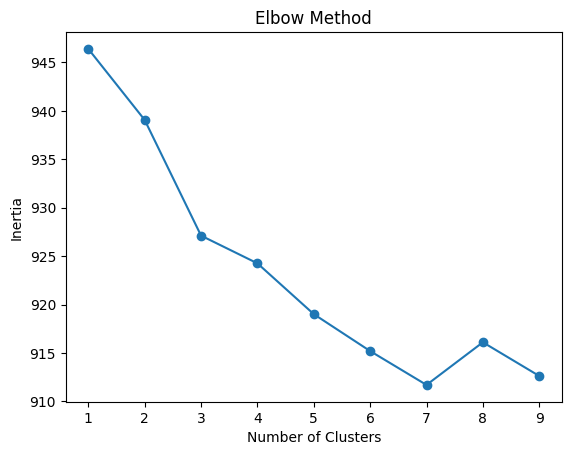

In [9]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [10]:
k = 3  # choose based on elbow method
kmeans = KMeans(n_clusters=k, random_state=42)

df['cluster'] = kmeans.fit_predict(X)
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished,text,clean_text,cluster
0,1.372182e+09,484,imgur.com,1h1si8,Seen near San Francisco,herbg22,536,52,31,http://www.reddit.com/r/Anticonsumption/commen...,NaN,NaN,False,http://c.thumbs.redditmedia.com/ZhxCSqlXF50Trv...,t5_2r83n,False,NaN,NaN,False,t3_1h1si8,http://imgur.com/NLfVFmZ,NaN,Seen near San Francisco,seen near san francisco,1
1,1.357513e+09,471,i.imgur.com,163165,Why do I get the feeling that society is tryin...,NaN,521,50,33,http://www.reddit.com/r/Anticonsumption/commen...,NaN,NaN,False,http://b.thumbs.redditmedia.com/mkyRF1k8xtbR5k...,t5_2r83n,False,NaN,NaN,False,t3_163165,http://i.imgur.com/kWhRO.jpg,NaN,Why do I get the feeling that society is tryin...,get feeling society trying make us discontente...,0
2,1.354373e+09,474,4.bp.blogspot.com,143qtm,The joy of not being sold anything.,andreasw,545,71,15,http://www.reddit.com/r/Anticonsumption/commen...,NaN,NaN,False,http://b.thumbs.redditmedia.com/hFsxErE7JeZT7r...,t5_2r83n,False,NaN,NaN,False,t3_143qtm,http://4.bp.blogspot.com/-9BX6-NUNsjA/UKlnlXQ3...,NaN,The joy of not being sold anything.,joy sold anything,1
3,1.367271e+09,432,i.imgur.com,1dd5yq,Graffiti Bad.,big_al11,497,65,47,http://www.reddit.com/r/Anticonsumption/commen...,NaN,NaN,False,http://c.thumbs.redditmedia.com/wYYf5IJ08w7JT0...,t5_2r83n,False,NaN,NaN,False,t3_1dd5yq,http://i.imgur.com/09nXC.gif,NaN,Graffiti Bad.,graffiti bad,1
4,1.374668e+09,389,i.imgur.com,1iy9gt,I found this. It hit me.,BerlinBesucher,518,129,66,http://www.reddit.com/r/Anticonsumption/commen...,NaN,NaN,False,http://d.thumbs.redditmedia.com/x0UL5RdYbuPxCi...,t5_2r83n,False,NaN,NaN,False,t3_1iy9gt,http://i.imgur.com/qTsjRNb.jpg,NaN,I found this. It hit me.,found hit,1


In [11]:
terms = vectorizer.get_feature_names_out()
centroids = kmeans.cluster_centers_

for i in range(k):
    print(f"\nCluster {i}:")
    top_terms = centroids[i].argsort()[-10:][::-1]
    for index in top_terms:
        print(terms[index])


Cluster 0:
dont
like
people
things
buy
need
life
want
im
think

Cluster 1:
consumerism
consumption
stuff
post
shopping
new
consumer
less
advertising
consumers

Cluster 2:
xpost
rminimalism
rpics
corporate
rfunny
stuff
american
food
year
dont


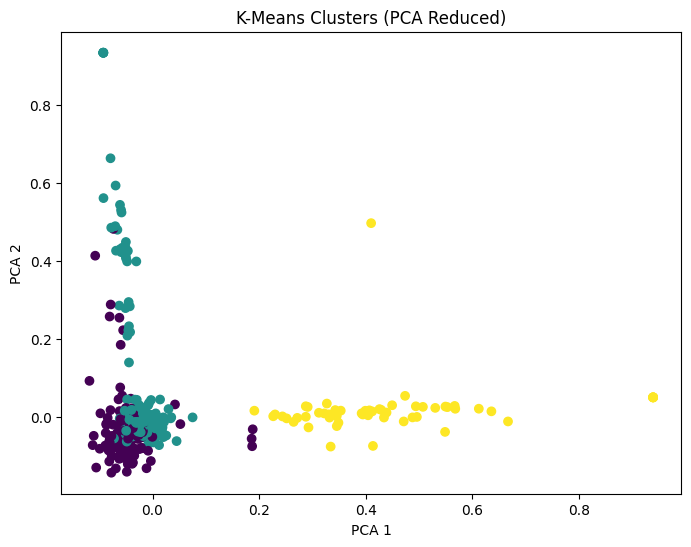

In [12]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=df['cluster'])
plt.title("K-Means Clusters (PCA Reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()